# 量子开放系统课程汇报--张量网络：第一部分

## 奇异值分解的两种理解

$$
A = U\Sigma V^\top = \sum_{i=1}^{r}\sigma_i u_i v_i^\top,
\qquad
\sigma_1 \ge \sigma_2 \ge \cdots \ge 0
$$

奇异值分解可以有的两种理解:

1. 几何理解：$V^\top \to \Sigma \to U$
2. 近似理解：保留前 $k$ 个奇异值得到最优 rank-$k$ 近似


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd
from PIL import Image
from pathlib import Path

np.set_printoptions(precision=4, suppress=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei",
    "SimHei",
    "Noto Sans CJK SC",
    "Arial Unicode MS",
    "DejaVu Sans",
]

## SVD 分解

$$
A_{m\times n}=U_{m\times m}\,\Sigma_{m\times n}\,V^\dagger_{n\times n},
\qquad
UU^\dagger=I_{m\times m},
\qquad
VV^\dagger=I_{n\times n}
$$

$$
\Sigma_{m\times n}\ \text{为对角阵，对角元称奇异值}
$$

1. 奇异值为非负实数；
2. 奇异值按降序排列。

$$
\Sigma=
\begin{pmatrix}
\sigma_1 & & & \\
& \sigma_2 & & \\
& & \ddots & \\
& & & \sigma_r
\end{pmatrix}
$$

$$
\sigma_1 \ge \sigma_2 \ge \cdots \ge \sigma_r > 0,
\qquad
r=\operatorname{rank}(A)
$$

当 $r<\min(m,n)$ 时，其余奇异值为 $0$。


## 例：一个 $2\times 3$ 矩阵

取

$$
A=
\begin{bmatrix}
3 & 2 & 2\\
2 & 3 & -2
\end{bmatrix}
$$

reduced SVD 为

$$
A = U\Sigma V^\top,
\qquad
U\in\mathbb{R}^{2\times 2},\quad
\Sigma\in\mathbb{R}^{2\times 2},\quad
V^\top\in\mathbb{R}^{2\times 3}
$$


In [38]:
A = np.array([
    [3.0, 2.0,  2.0],
    [2.0, 3.0, -2.0],
])

U_A, s_A, Vt_A = np.linalg.svd(A, full_matrices=False)
Sigma_A = np.diag(s_A)

print("A =")
print(A)
print("\nU shape =", U_A.shape)
print("Sigma shape =", Sigma_A.shape)
print("V^T shape =", Vt_A.shape)
print("\n奇异值 =", s_A)
print("\n重构误差 ||A-UΣV^T|| =", np.linalg.norm(A - U_A @ Sigma_A @ Vt_A))

A =
[[ 3.  2.  2.]
 [ 2.  3. -2.]]

U shape = (2, 2)
Sigma shape = (2, 2)
V^T shape = (2, 3)

奇异值 = [5. 3.]

重构误差 ||A-UΣV^T|| = 1.041481514324134e-15


补充说明：若 $A\in\mathbb{R}^{m\times n}$ 的秩为 $r$，则 reduced SVD 写成

$$
A = U\Sigma V^\top,
\qquad
U\in\mathbb{R}^{m\times r},\quad
\Sigma\in\mathbb{R}^{r\times r},\quad
V\in\mathbb{R}^{n\times r}
$$

其中 $r=\operatorname{rank}(A)$，非零奇异值个数恰为矩阵的秩。对上面的例子，

$$
r=2,
\qquad
\sigma_1=5,
\quad
\sigma_2=3
$$

因此该矩阵是满行秩矩阵，但不是方阵。


## 理解一：几何分解

对于方阵变换

$$
M = U\Sigma V^\top
$$

可分三步理解：

1. $V^\top$：把 right singular vectors 旋到标准基
2. $\Sigma$：沿坐标轴拉伸；若某个 $\sigma_i=0$，则对应坐标轴被移除
3. $U$：把标准基再旋到 left singular vectors 的方向


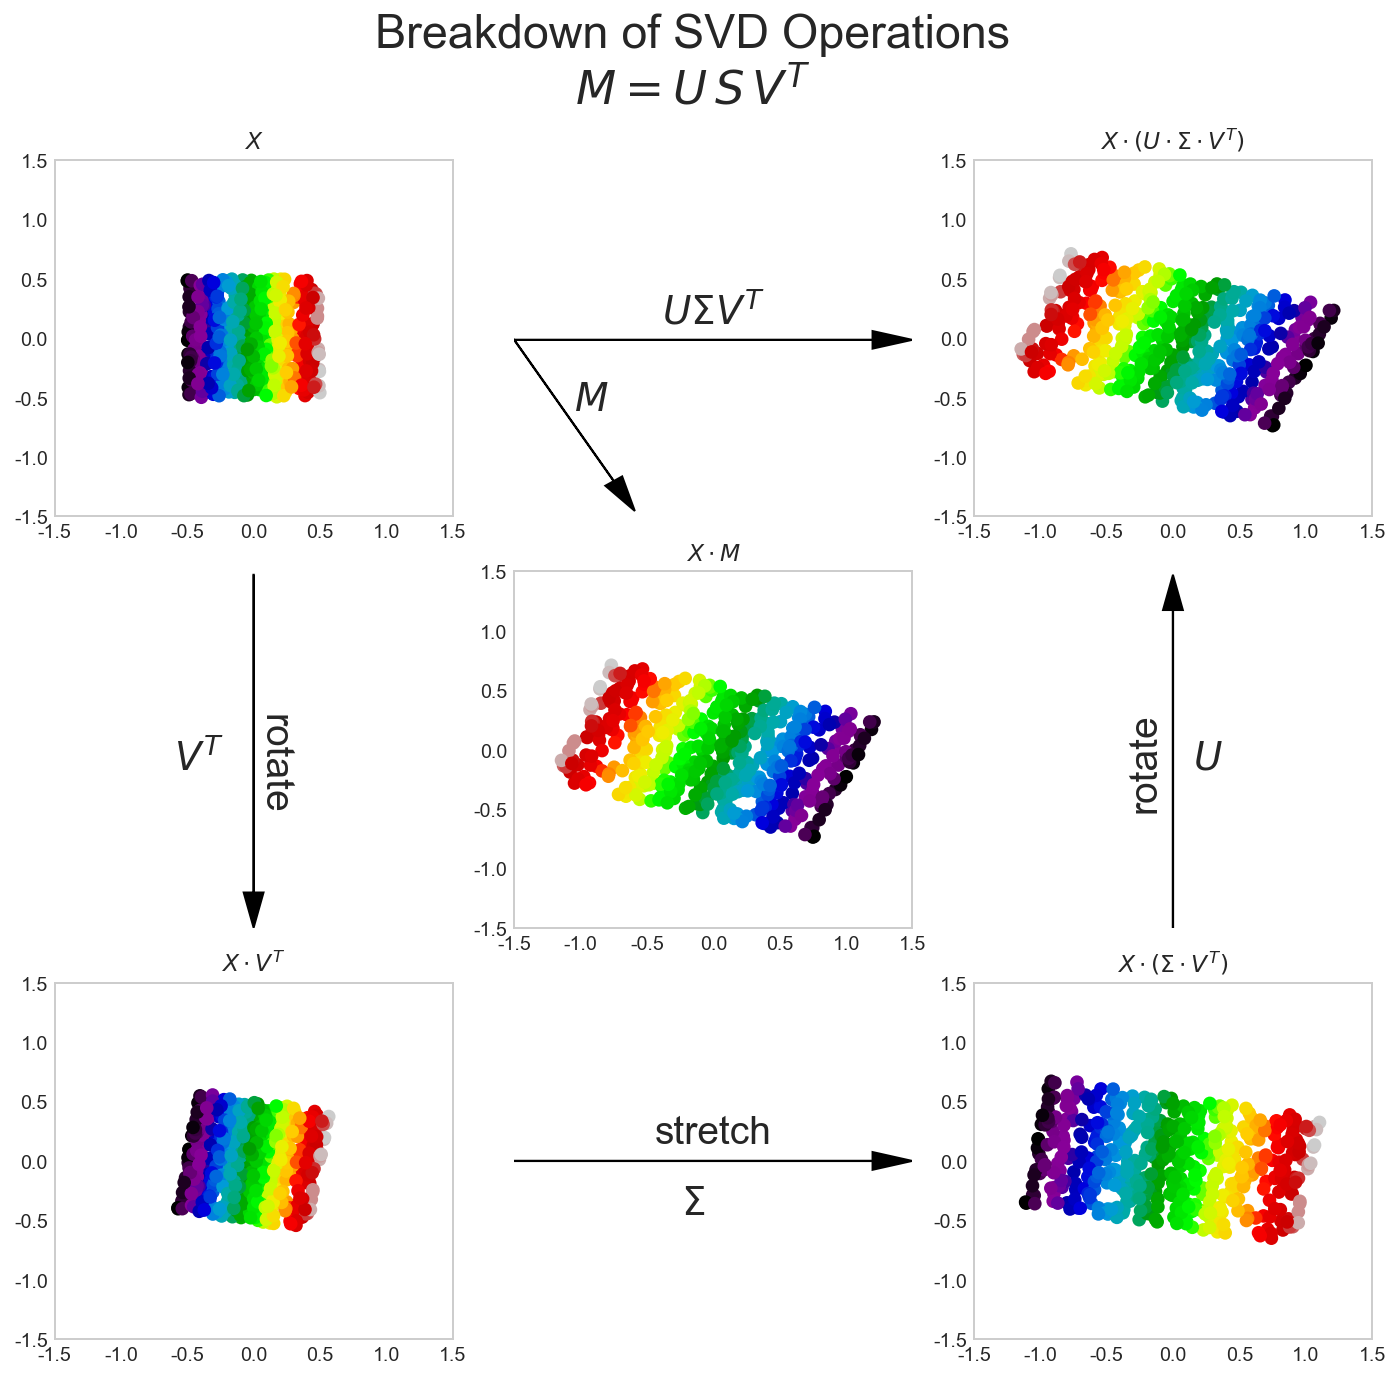

奇异值 = [2.0811 1.0811]
||M - UΣV^T|| = 9.222205069512407e-16
||XM - X(UΣV^T)|| = 5.986951190467391e-15


In [39]:
np.random.seed(123)
n_observations = 500
n_dim = 2
X = np.random.rand(n_observations, n_dim) - 0.5

M = np.array([
    [-2.0,  0.5],
    [-0.5, -1.0],
])

colors = X[:, 0]
cmap = "nipy_spectral"

U, singular_values, Vt = svd(M)
S = np.diag(singular_values)

fig, axs = plt.subplots(3, 3, figsize=(10, 10))
plt.suptitle("Breakdown of SVD Operations\n$M = U\\,S\\,V^T$", fontsize=24, ha="center")

plt.sca(axs[0][0])
plt.scatter(X[:, 0], X[:, 1], c=colors, cmap=cmap)
plt.xlim([-1.5, 1.5]); plt.ylim([-1.5, 1.5]); plt.grid()
plt.title("$X$")

XM = X @ M
plt.sca(axs[1][1])
plt.scatter(XM[:, 0], XM[:, 1], c=colors, cmap=cmap)
plt.xlim([-1.5, 1.5]); plt.ylim([-1.5, 1.5]); plt.grid()
plt.title("$X \\cdot M$")

XVt = X @ Vt
plt.sca(axs[2][0])
plt.scatter(XVt[:, 0], XVt[:, 1], c=colors, cmap=cmap)
plt.xlim([-1.5, 1.5]); plt.ylim([-1.5, 1.5]); plt.grid()
plt.title("$X \\cdot V^T$")

XSVt = X @ (S @ Vt)
plt.sca(axs[2][2])
plt.scatter(XSVt[:, 0], XSVt[:, 1], c=colors, cmap=cmap)
plt.xlim([-1.5, 1.5]); plt.ylim([-1.5, 1.5]); plt.grid()
plt.title("$X \\cdot (\\Sigma \\cdot V^T)$")

XUSVt = X @ (U @ S @ Vt)
plt.sca(axs[0][2])
plt.scatter(XUSVt[:, 0], XUSVt[:, 1], c=colors, cmap=cmap)
plt.xlim([-1.5, 1.5]); plt.ylim([-1.5, 1.5]); plt.grid()
plt.title("$X \\cdot (U \\cdot \\Sigma \\cdot V^T)$")

plt.sca(axs[0][1])
plt.arrow(0.0, 0.5, 0.9, 0.0, capstyle="round", head_width=0.05, head_length=0.1, fc="black")
plt.arrow(0.0, 0.5, 0.25, -0.4, capstyle="round", head_width=0.05, head_length=0.1, fc="black")
plt.text(0.15, 0.3, "$M$", fontsize=20)
plt.text(0.5, 0.55, "$U\\Sigma V^T$", fontsize=20, ha="center")
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.01]); plt.axis("off")

plt.sca(axs[1][0])
plt.arrow(0.5, 1.0, 0.0, -0.9, capstyle="round", head_width=0.05, head_length=0.1, fc="black")
plt.text(0.3, 0.45, "$V^T$", fontsize=20)
plt.text(0.55, 0.35, "rotate", fontsize=20, ha="center", rotation=-90)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.01]); plt.axis("off")

plt.sca(axs[2][1])
plt.arrow(0.0, 0.5, 0.9, 0.0, capstyle="round", head_width=0.05, head_length=0.1, fc="black")
plt.text(0.42, 0.35, "$\\Sigma$", fontsize=20)
plt.text(0.5, 0.55, "stretch", fontsize=20, ha="center")
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.0]); plt.axis("off")

plt.sca(axs[1][2])
plt.arrow(0.5, 0.0, 0.0, 0.9, capstyle="round", head_width=0.05, head_length=0.1, fc="black")
plt.text(0.55, 0.45, "$U$", fontsize=20)
plt.text(0.43, 0.35, "rotate", fontsize=20, ha="center", rotation=90)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.01]); plt.axis("off")

plt.tight_layout()
plt.show()

print("奇异值 =", singular_values)
print("||M - UΣV^T|| =", np.linalg.norm(M - U @ S @ Vt))
print("||XM - X(UΣV^T)|| =", np.linalg.norm(XM - XUSVt))

几何上，

$$
V^\top:\ \text{选取输入空间中的主方向}
$$

$$
\Sigma:\ \text{沿标准坐标轴缩放}
$$

$$
U:\ \text{把标准基转到输出空间主方向}
$$


更严格地说，$U$ 与 $V$ 都是正交矩阵（或列正交矩阵），满足

$$
U^\top U = I,
\qquad
V^\top V = I
$$

因此它们保持内积、长度与夹角；真正改变尺度的是 $\Sigma$。这就是为什么奇异值分解能把“方向变化”和“尺度变化”清楚分离。


## 理解二：low-rank 近似

由

$$
A = \sum_{i=1}^{r}\sigma_i u_i v_i^\top
$$

截断得到

$$
A_k = \sum_{i=1}^{k}\sigma_i u_i v_i^\top
$$

则 $A_k$ 是最优 rank-$k$ 近似：

$$
A_k = \arg\min_{\operatorname{rank}(B)\le k}\|A-B\|_F
$$

把灰度图像看成矩阵后，截断 SVD 就对应图像压缩。


这里的 low-rank 近似不是经验性的，而是严格最优的。除了 Frobenius 范数外，在谱范数下也成立：

$$
\|A-A_k\|_2 = \sigma_{k+1},
\qquad
\|A-A_k\|_F^2 = \sum_{i>k}\sigma_i^2
$$

因此奇异值衰减越快，截断后的近似越有效；这也是后续张量截断能够成立的数学基础。


image shape = (500, 500)
k    rel_error      parameters
--------------------------------
5   0.201820       5005
20  0.104151       20020
50  0.058932       50050
75  0.041544       75075
100 0.030387       100100


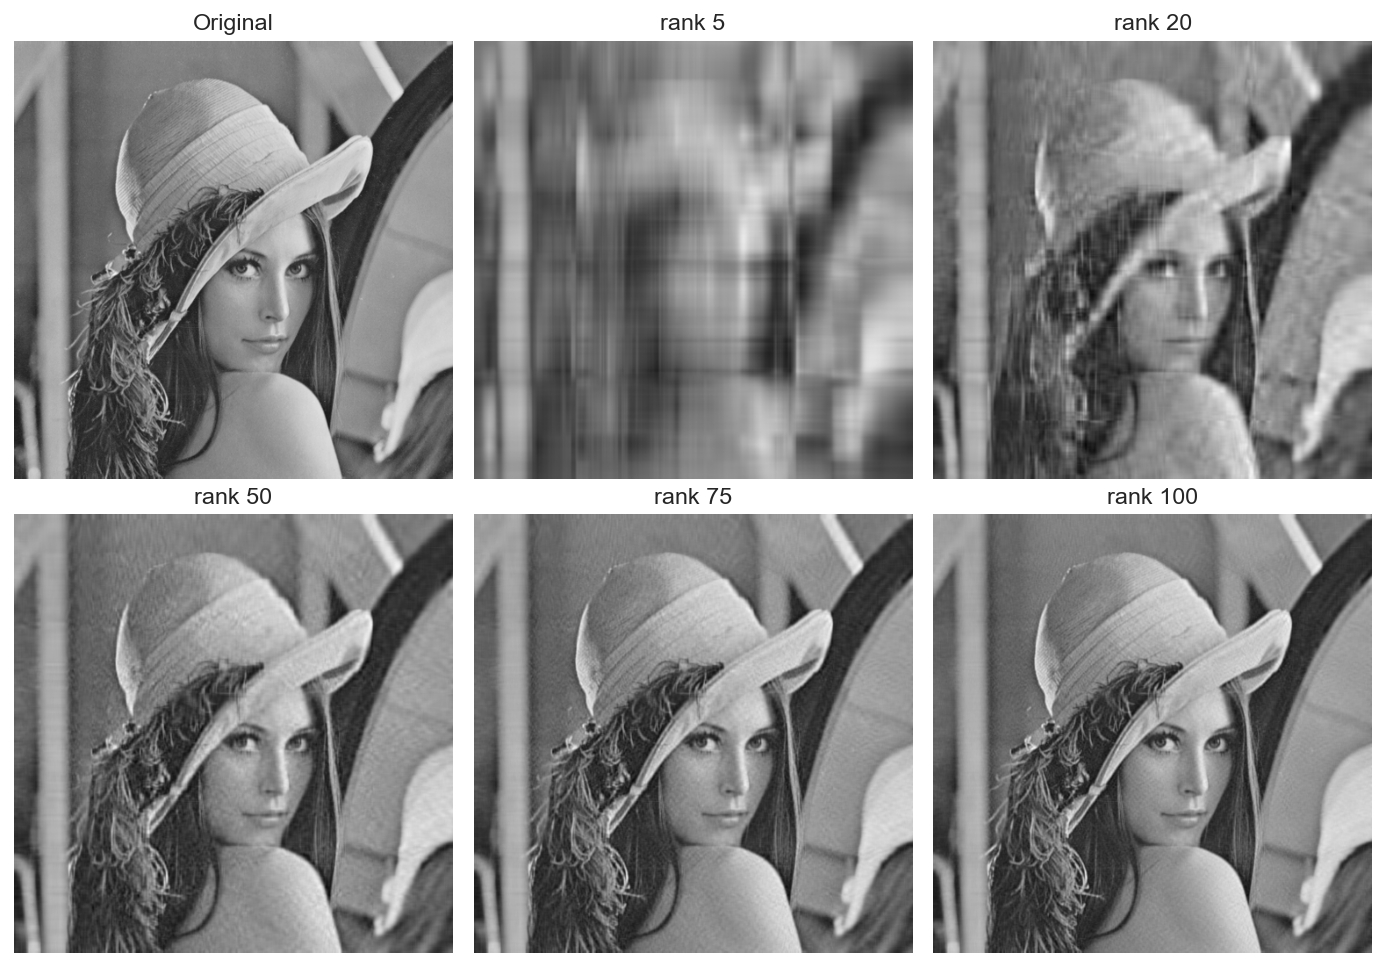

In [40]:
img_path = Path("Lenna.png")
img = np.asarray(Image.open(img_path).convert("L"), dtype=float) / 255.0

U_img, s_img, Vt_img = np.linalg.svd(img, full_matrices=False)

def svd_rank_k(k: int):
    return (U_img[:, :k] * s_img[:k]) @ Vt_img[:k, :]

ks = [5, 20, 50, 75, 100]
m, n = img.shape

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
axes = axes.ravel()

axes[0].imshow(img, cmap="gray", vmin=0.0, vmax=1.0)
axes[0].set_title("Original")
axes[0].axis("off")

print(f"image shape = {img.shape}")
print("k    rel_error      parameters")
print("-" * 32)

for ax, k in zip(axes[1:], ks):
    img_k = svd_rank_k(k)
    rel_error = np.linalg.norm(img - img_k) / np.linalg.norm(img)
    params = m * k + k + k * n
    ax.imshow(img_k, cmap="gray", vmin=0.0, vmax=1.0)
    ax.set_title(f"rank {k}")
    ax.axis("off")
    print(f"{k:<4}{rel_error:<15.6f}{params}")

plt.tight_layout()
plt.show()

## 小结

$$
A = U\Sigma V^\top
$$

给出几何分解；

$$
A_k = \sum_{i=1}^{k}\sigma_i u_i v_i^\top
$$

给出最优 low-rank 近似。后面的 MPS / TT-SVD，本质上就是不断重复这个思想。


# 量子开放系统课程汇报--张量网络：第二部分

## 张量的图表示与TT分解


### 1. 张量的图表示 (Tensor Diagrammatic Representation)

在张量网络中，我们通常使用图形化的方式来表示张量及其运算。这种表示法在量子开放系统中极其有用，因为它可以简化复杂的下标求和运算。

- **标量 (Scalar)**: 一个节点，没有边。
- **向量 (Vector)**: 一个节点，带有一条边。$v_i$ 表示第 $i$ 个分量。
- **矩阵 (Matrix)**: 一个节点，带有两条边。$M_{ij}$ 表示矩阵的元素。
- **高阶张量 (Higher-order Tensor)**: 一个节点，带有三条或更多条边。

**张量缩并 (Tensor Contraction)**:
两条边相连表示对相应的指标进行求和（即 Einstein 求和约定）。
例如，矩阵乘法 $C_{ik} = \sum_j A_{ij} B_{jk}$ 在图中表示为：
将张量 $A$ 的一条边与张量 $B$ 的一条边相连。

#### 图示示例

1. **内积**: 两个向量各有一条边，连接这两条边。
2. **矩阵-向量乘法**: 矩阵有两条边，向量有一条边，连接其中一条。
3. **矩阵乘法**: 两个矩阵各有两条边，连接中间相匹配的维度。


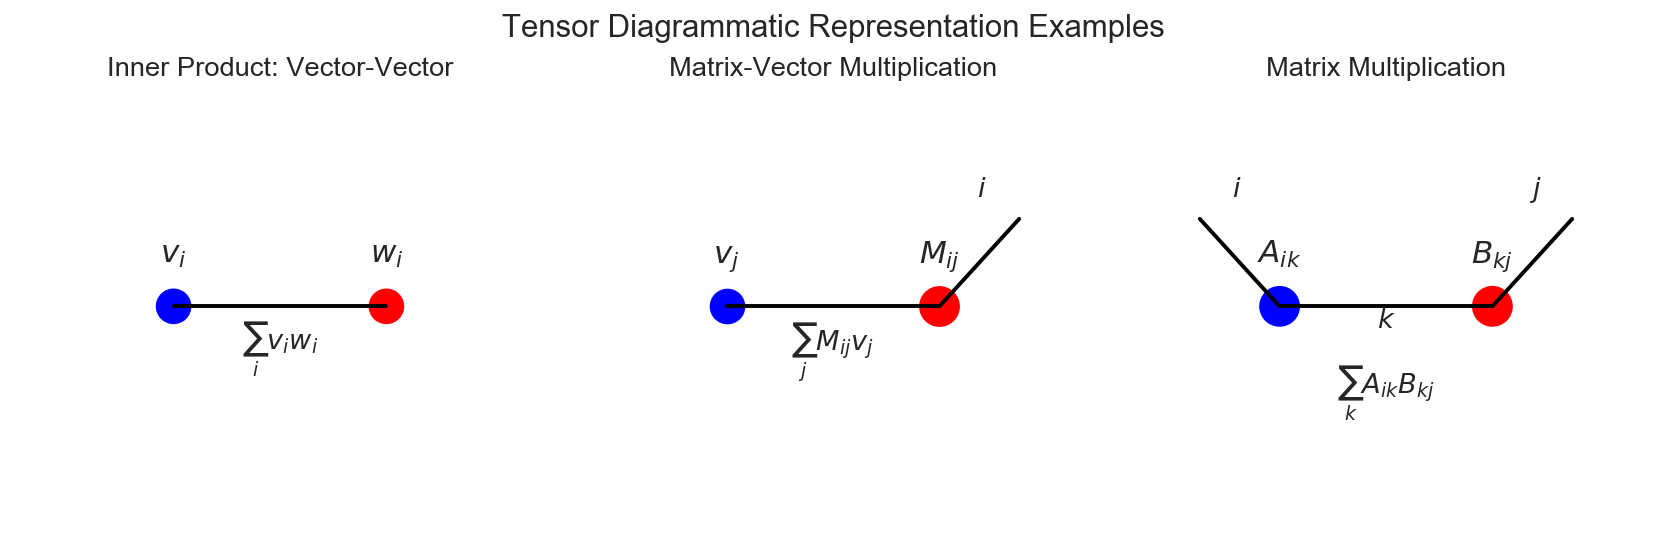

In [41]:
# Create visualizations for tensor diagrammatic representation
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# 1. Inner product (vector-vector)
ax = axes[0]
# Create two vector nodes
ax.scatter([0.3, 0.7], [0.5, 0.5], s=300, c=['blue', 'red'])
# Add connecting edge
ax.plot([0.3, 0.7], [0.5, 0.5], 'k-', linewidth=2)
# Add labels
ax.text(0.3, 0.6, r'$v_i$', fontsize=16, ha='center')
ax.text(0.7, 0.6, r'$w_i$', fontsize=16, ha='center')
ax.text(0.5, 0.4, r'$\sum_i v_i w_i$', fontsize=14, ha='center')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('Inner Product: Vector-Vector', fontsize=14)
ax.axis('off')

# 2. Matrix-vector multiplication
ax = axes[1]
# Create matrix and vector nodes
ax.scatter([0.3], [0.5], s=300, c='blue')  # vector
ax.scatter([0.7], [0.5], s=400, c='red')   # matrix
# Add connecting edge
ax.plot([0.3, 0.7], [0.5, 0.5], 'k-', linewidth=2)
# Add free edge for matrix
ax.plot([0.7, 0.85], [0.5, 0.7], 'k-', linewidth=2)
# Add labels
ax.text(0.3, 0.6, r'$v_j$', fontsize=16, ha='center')
ax.text(0.7, 0.6, r'$M_{ij}$', fontsize=16, ha='center')
ax.text(0.78, 0.75, r'$i$', fontsize=14, ha='center')
ax.text(0.5, 0.4, r'$\sum_j M_{ij} v_j$', fontsize=14, ha='center')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('Matrix-Vector Multiplication', fontsize=14)
ax.axis('off')

# 3. Matrix multiplication
ax = axes[2]
# Create two matrix nodes
ax.scatter([0.3, 0.7], [0.5, 0.5], s=400, c=['blue', 'red'])
# Add connecting edge
ax.plot([0.3, 0.7], [0.5, 0.5], 'k-', linewidth=2)
# Add free edges
ax.plot([0.3, 0.15], [0.5, 0.7], 'k-', linewidth=2)  # left matrix free edge
ax.plot([0.7, 0.85], [0.5, 0.7], 'k-', linewidth=2)  # right matrix free edge
# Add labels
ax.text(0.3, 0.6, r'$A_{ik}$', fontsize=16, ha='center')
ax.text(0.7, 0.6, r'$B_{kj}$', fontsize=16, ha='center')
ax.text(0.22, 0.75, r'$i$', fontsize=14, ha='center')
ax.text(0.5, 0.45, r'$k$', fontsize=14, ha='center')
ax.text(0.78, 0.75, r'$j$', fontsize=14, ha='center')
ax.text(0.5, 0.3, r'$\sum_k A_{ik} B_{kj}$', fontsize=14, ha='center')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('Matrix Multiplication', fontsize=14)
ax.axis('off')

plt.suptitle('Tensor Diagrammatic Representation Examples', fontsize=16, y=0.95)
plt.tight_layout()
plt.show()

### 2. Tensor-train 分解

#### 2.1 基本定义

给定 $N$ 阶张量 $T_{s_1\cdots s_N}$，TT 分解将其写为一组低阶核张量的链式缩并：

$$
T_{s_1\cdots s_N}
=\sum_{a_1,\ldots,a_{N-1}}
A^{(1)}_{s_1 a_1}A^{(2)}_{s_2 a_1 a_2}\cdots A^{(N)}_{s_N a_{N-1}}.
$$

其中 $a_n$ 为辅助指标（bond index）。通常两端核张量为二阶，中间核张量为三阶。该表示在量子多体问题中对应矩阵乘积态（MPS）形式。

#### 2.2 四阶张量示例

对四阶张量 $T_{s_1s_2s_3s_4}$，有

$$
T_{s_1s_2s_3s_4}=\sum_{a_1,a_2,a_3}
A^{(1)}_{s_1a_1}A^{(2)}_{s_2a_1a_2}A^{(3)}_{s_3a_2a_3}A^{(4)}_{s_4a_3}.
$$

上述缩并过程称为 TT 积。

#### 2.3 计算框架（TT-SVD / TT-QR）

TT 分解可通过逐步展开与矩阵分解实现：

1. 将当前张量按前后指标重排为矩阵；
2. 对该矩阵执行 SVD（或 QR）分解；
3. 将左因子重塑为当前核张量；
4. 将剩余部分传递到下一步继续分解。

该过程共进行 $N-1$ 次。

#### 2.4 TT 秩与最优 TT 低秩近似

- 无截断时，辅助指标维数给出 TT 秩序列 $(r_1,\ldots,r_{N-1})$；
- 在高维问题中，若不进行截断，TT 秩可能迅速增大，仍面临指数复杂度。

为控制复杂度，通常引入截断维数上限 $\chi$，并考虑如下优化问题：

$$
\min_{\dim(a_n)\le\chi}\|T-\tilde T\|_F.
$$

若近似张量 $\tilde T$ 达到上述最小值，则称其为给定截断维数约束下的**最优 TT 低秩近似**。在算法上，TT-SVD 通过逐步保留主导奇异值来构造该近似（或其高质量近似），体现了精度与压缩率之间的权衡。


In [42]:

import numpy as np

rng = np.random.default_rng(42)

# 物理维数（s1,s2,s3,s4）
d1 = d2 = d3 = d4 = 4
# 辅助维数（a1,a2,a3）
r1, r2, r3 = 3, 5, 2

A1 = rng.normal(size=(d1, r1))
A2 = rng.normal(size=(d2, r1, r2))
A3 = rng.normal(size=(d3, r2, r3))
A4 = rng.normal(size=(d4, r3))

# T[s1,s2,s3,s4] = sum_{a1,a2,a3} A1[s1,a1] A2[s2,a1,a2] A3[s3,a2,a3] A4[s4,a3]
T = np.einsum("ia,jab,kbc,lc->ijkl", A1, A2, A3, A4)


print("Step 1. 随机生成 4 个 TT 核张量（A^(1)~A^(4)）")
print(f"  A^(1) shape = {A1.shape}")
print(f"  A^(2) shape = {A2.shape}")
print(f"  A^(3) shape = {A3.shape}")
print(f"  A^(4) shape = {A4.shape}")

print("\nStep 2. 进行缩并（einsum）得到目标四阶张量 T")
print(f"  T shape      = {T.shape}")
print(f"  ||T||_F      = {np.linalg.norm(T):.4f}")


Step 1. 随机生成 4 个 TT 核张量（A^(1)~A^(4)）
  A^(1) shape = (4, 3)
  A^(2) shape = (4, 3, 5)
  A^(3) shape = (4, 5, 2)
  A^(4) shape = (4, 2)

Step 2. 进行缩并（einsum）得到目标四阶张量 T
  T shape      = (4, 4, 4, 4)
  ||T||_F      = 32.2864


In [47]:

def tt_svd(tensor, chi=None, eps=None):
    """
    TT-SVD with optional rank truncation.
    chi: 每个 bond 的最大截断维数
    eps: 相对阈值，保留 s_i > eps * s_1 的奇异值
    """
    dims = tensor.shape
    N = len(dims)
    cores = []
    ranks = [1]

    C = tensor.copy()
    r_prev = 1

    for n in range(N - 1):
        C = C.reshape(r_prev * dims[n], -1)
        U, S, Vh = np.linalg.svd(C, full_matrices=False)

        r = len(S)
        if eps is not None and len(S) > 0:
            r = min(r, int(np.sum(S > eps * S[0])))
            r = max(r, 1)
        if chi is not None:
            r = min(r, chi)

        U = U[:, :r]
        S = S[:r]
        Vh = Vh[:r, :]

        core = U.reshape(r_prev, dims[n], r)
        cores.append(core)
        ranks.append(r)

        C = np.diag(S) @ Vh
        r_prev = r

    cores.append(C.reshape(r_prev, dims[-1], 1))
    ranks.append(1)
    return cores, ranks


def tt_reconstruct(cores):
    X = cores[0]
    for n in range(1, len(cores)):
        X = np.tensordot(X, cores[n], axes=([-1], [0]))
    # (1, d1, d2, ..., dN, 1) -> (d1, d2, ..., dN)
    return np.squeeze(X, axis=(0, -1))


def tt_param_count(cores):
    return int(sum(core.size for core in cores))


rng = np.random.default_rng(2026)
T4 = rng.normal(size=(10, 10, 10, 10))
full_params = T4.size
chis = [2, 4, 8, 10, 20, 30, 40, 50, 75, 100]


print(f"原始张量维度: {T4.shape}")
print(f"原始参数量  : {full_params}")
print("\n逐个测试不同截断维数 chi：")
print("-" * 92)
print(f"{'chi':>5} {'TT-ranks':>20} {'rel_err':>14} {'params':>10} {'compression':>14}")
print("-" * 92)

best_rel_err = None
best_chi = None

for chi in chis:
    cores, ranks = tt_svd(T4, chi=chi)
    T4_hat = tt_reconstruct(cores)
    rel_err = np.linalg.norm(T4 - T4_hat) / np.linalg.norm(T4)
    params = tt_param_count(cores)
    compression = full_params / params

    print(f"{chi:>5d} {str(ranks):>20} {rel_err:>14.3e} {params:>10d} {compression:>13.2f}x")

    if best_rel_err is None or rel_err < best_rel_err:
        best_rel_err = rel_err
        best_chi = chi



原始张量维度: (10, 10, 10, 10)
原始参数量  : 10000

逐个测试不同截断维数 chi：
--------------------------------------------------------------------------------------------
  chi             TT-ranks        rel_err     params    compression
--------------------------------------------------------------------------------------------
    2      [1, 2, 2, 2, 1]      9.906e-01        120         83.33x
    4      [1, 4, 4, 4, 1]      9.691e-01        400         25.00x
    8      [1, 8, 8, 8, 1]      8.871e-01       1440          6.94x
   10   [1, 10, 10, 10, 1]      8.260e-01       2200          4.55x
   20   [1, 10, 20, 10, 1]      6.781e-01       4200          2.38x
   30   [1, 10, 30, 10, 1]      5.452e-01       6200          1.61x
   40   [1, 10, 40, 10, 1]      4.290e-01       8200          1.22x
   50   [1, 10, 50, 10, 1]      3.234e-01      10200          0.98x
   75   [1, 10, 75, 10, 1]      1.126e-01      15200          0.66x
  100  [1, 10, 100, 10, 1]      2.871e-15      20200          0.50x


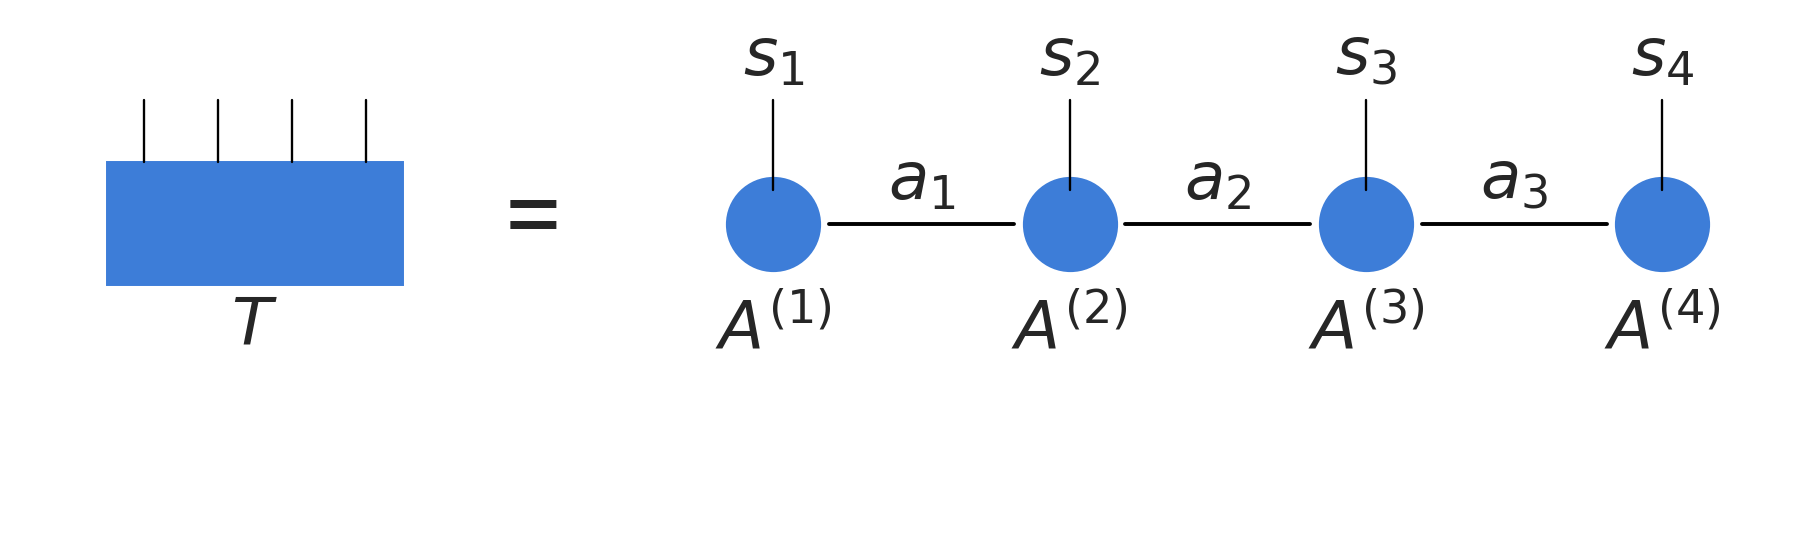

In [ ]:

from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(13, 4))

node_color = "#3d7dd8"

# 左侧原始四阶张量节点 T（纯色长方形）
xT, yT = 0.16, 0.52
rect_w, rect_h = 0.16, 0.20
rect_left = Rectangle((xT - rect_w / 2, yT - rect_h / 2), rect_w, rect_h, facecolor=node_color, edgecolor=node_color)


# T 的四条物理腿
for dx in [-0.06, -0.02, 0.02, 0.06]:
    ax.plot([xT + dx, xT + dx], [yT + rect_h / 2, yT + 0.20], "k-", linewidth=1.2, zorder=100)
ax.add_patch(rect_left)
ax.text(xT, yT - 0.12, r"$T$", fontsize=34, ha="center", va="top")


ax.text(0.31, 0.52, "=", fontsize=50, ha="center", va="center")

# 右侧四个 TT 核（圆形单色）
core_x = [0.44, 0.60, 0.76, 0.92]
core_y = 0.52


# 物理腿 s1~s4
for i, x in enumerate(core_x, start=1):
    ax.plot([x, x], [core_y + 0.055, core_y + 0.20], "k-", linewidth=1.2)
    ax.text(x, core_y + 0.22, rf"$s_{i}$", fontsize=34, ha="center", va="bottom")
    ax.text(x, core_y - 0.12, rf"$A^{{({i})}}$", fontsize=34, ha="center", va="top")

# bond 连线与 a1,a2,a3（与示例统一：'k-' + linewidth=2）
for i in range(3):
    x1, x2 = core_x[i], core_x[i + 1]
    ax.plot([x1 + 0.03, x2 - 0.03], [core_y, core_y], "k-", linewidth=2)
    ax.text((x1 + x2) / 2, core_y + 0.04, rf"$a_{i+1}$", fontsize=34, ha="center")

ax.scatter(core_x, [core_y] * 4, s=2300, c=node_color)

ax.set_xlim(0.03, 0.99)
ax.set_ylim(0.02, 0.86)
ax.axis("off")
plt.tight_layout()
plt.show()